In [1]:
import numpy as np
import pandas as pd

from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Reshape, Conv1D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv('../cardiovascular_diseases_processed.csv')
df.head()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1
3,48,2,169,82,150,100,1,1,0,0,1,1
4,48,1,156,56,100,60,1,1,0,0,0,0


In [3]:
df.shape

(68783, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68783 entries, 0 to 68782
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   AGE                68783 non-null  int64
 1   GENDER             68783 non-null  int64
 2   HEIGHT             68783 non-null  int64
 3   WEIGHT             68783 non-null  int64
 4   AP_HIGH            68783 non-null  int64
 5   AP_LOW             68783 non-null  int64
 6   CHOLESTEROL        68783 non-null  int64
 7   GLUCOSE            68783 non-null  int64
 8   SMOKE              68783 non-null  int64
 9   ALCOHOL            68783 non-null  int64
 10  PHYSICAL_ACTIVITY  68783 non-null  int64
 11  CARDIO_DISEASE     68783 non-null  int64
dtypes: int64(12)
memory usage: 6.3 MB


In [5]:
df.describe()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
count,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000
mean,53.326781,1.348749,164.361252,74.121934,126.614585,81.381591,1.364727,1.225986,0.088001,0.053632,0.803367,0.494904
std,6.768163,0.476578,8.184850,14.331392,16.763763,9.676679,0.678976,0.571961,0.283299,0.225293,0.397455,0.499978
min,30.000000,1.000000,55.000000,11.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,240.000000,190.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
print(df.isnull().sum())

AGE                  0
GENDER               0
HEIGHT               0
WEIGHT               0
AP_HIGH              0
AP_LOW               0
CHOLESTEROL          0
GLUCOSE              0
SMOKE                0
ALCOHOL              0
PHYSICAL_ACTIVITY    0
CARDIO_DISEASE       0
dtype: int64


In [7]:
for column in df.columns:
    num_unique_values = df[column].nunique()
    print(f'Number of unique values in {column}: {num_unique_values}')

Number of unique values in AGE: 28
Number of unique values in GENDER: 2
Number of unique values in HEIGHT: 106
Number of unique values in WEIGHT: 152
Number of unique values in AP_HIGH: 108
Number of unique values in AP_LOW: 84
Number of unique values in CHOLESTEROL: 3
Number of unique values in GLUCOSE: 3
Number of unique values in SMOKE: 2
Number of unique values in ALCOHOL: 2
Number of unique values in PHYSICAL_ACTIVITY: 2
Number of unique values in CARDIO_DISEASE: 2


In [8]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
print(outliers)

0        False
1        False
2         True
3        False
4         True
         ...  
68778     True
68779     True
68780     True
68781     True
68782    False
Length: 68783, dtype: bool


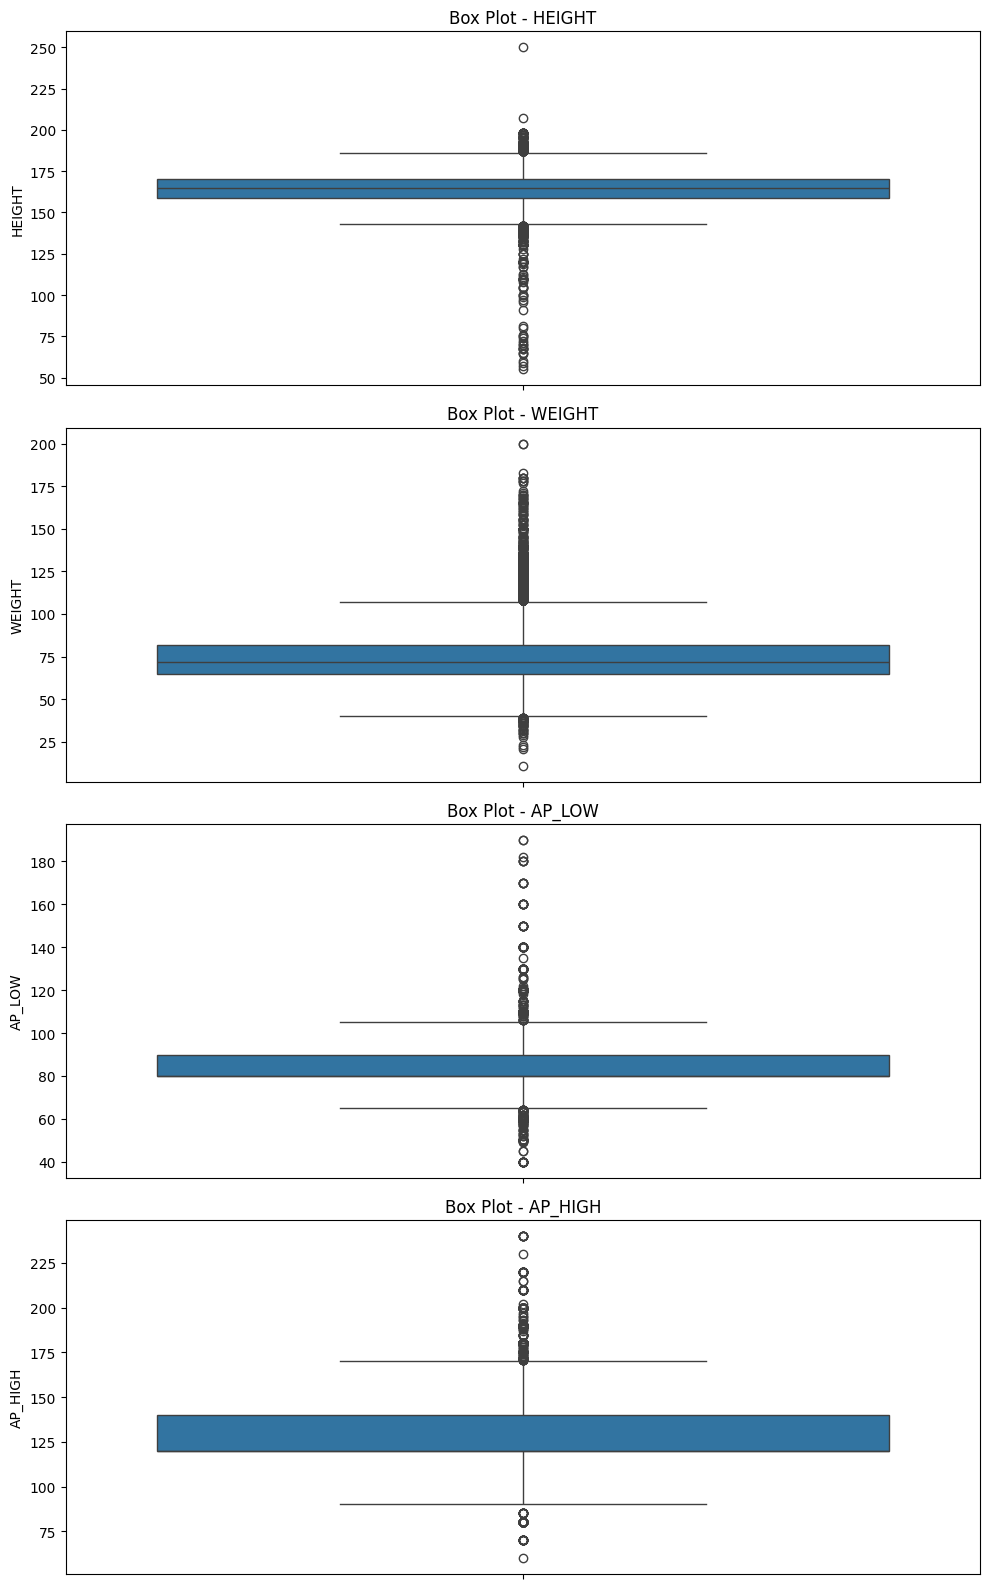

HEIGHT: 507 outliers (0.74%)
WEIGHT: 1748 outliers (2.54%)
AP_LOW: 3599 outliers (5.23%)
AP_HIGH: 1068 outliers (1.55%)


In [9]:

columns = ['HEIGHT', 'WEIGHT', 'AP_LOW', 'AP_HIGH']
selected_cols = [col for col in columns if col in df.columns]

fig, axes = plt.subplots(len(selected_cols), 1, figsize=(10, 4*len(selected_cols)), squeeze=False)
axes = axes.flatten()

for idx, col in enumerate(selected_cols):
    sns.boxplot(data=df, y=col, ax=axes[idx])
    axes[idx].set_title(f'Box Plot - {col}')

plt.tight_layout()
plt.show()

for col in selected_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({(len(outliers)/len(df)*100):.2f}%)")

In [10]:
df = df[(df['AP_HIGH'] > 80) & (df['AP_HIGH'] < 250)]
df = df[(df['AP_LOW'] > 40) & (df['AP_LOW'] < 150)]

df = df[(df['HEIGHT'] > 120) & (df['HEIGHT'] < 220)]
df = df[(df['WEIGHT'] > 30) & (df['WEIGHT'] < 200)]

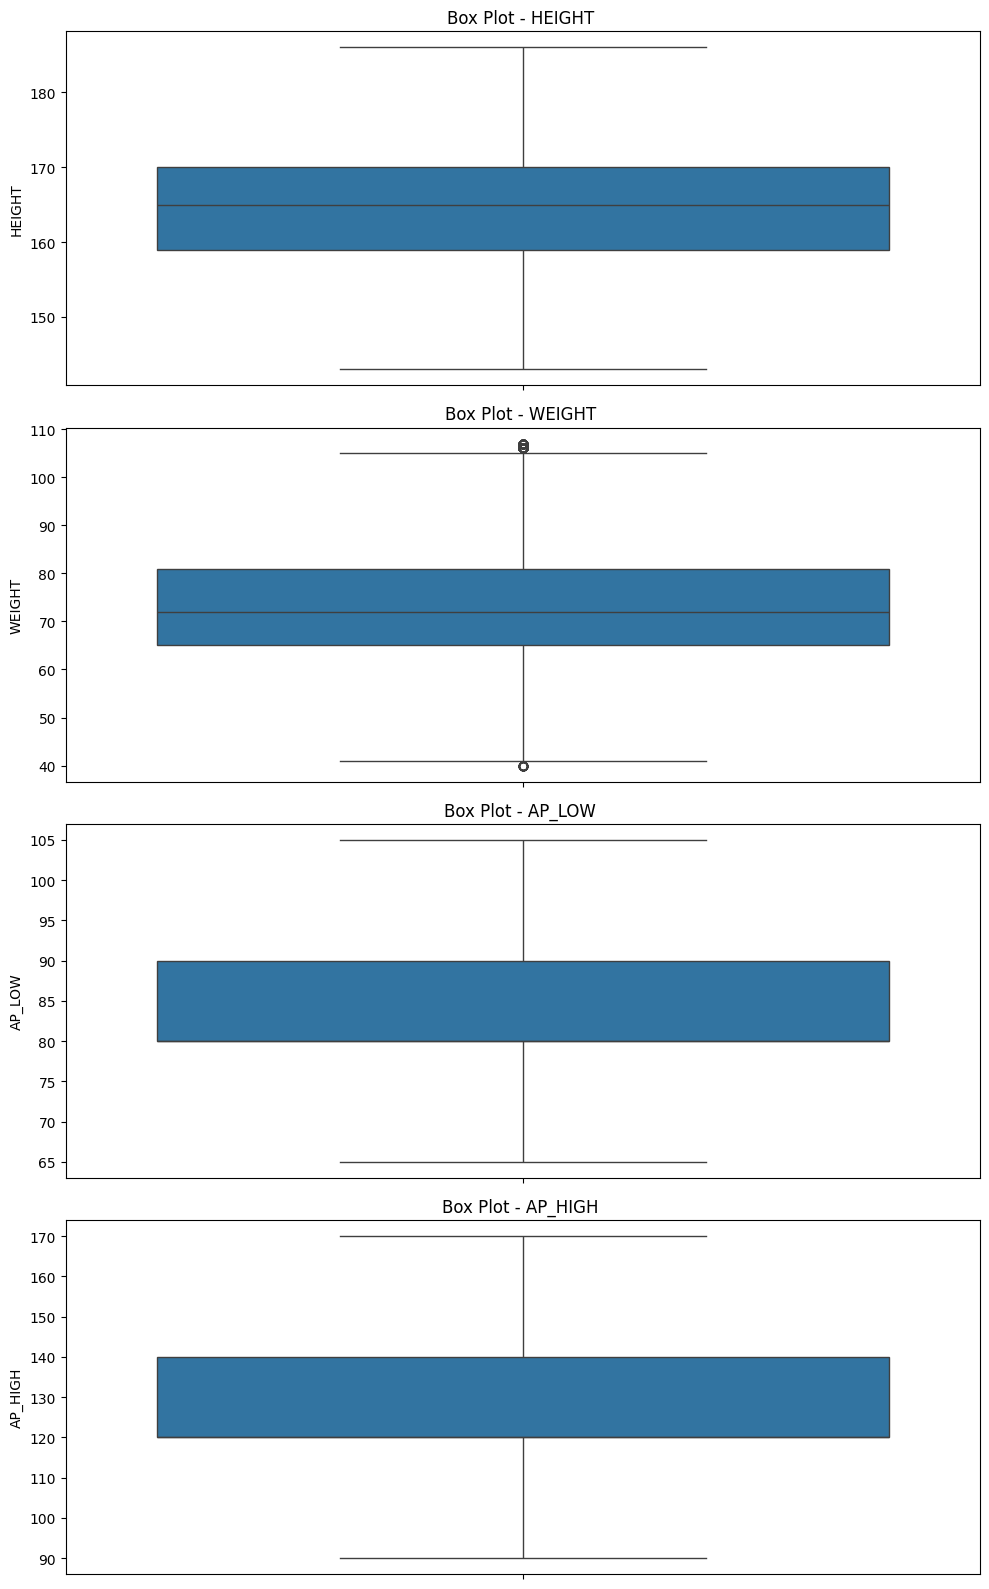

In [11]:
df_cleaned = df.copy()

for col in selected_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]


fig, axes = plt.subplots(len(selected_cols), 1, figsize=(10, 4*len(selected_cols)), squeeze=False)
axes = axes.flatten()

for idx, col in enumerate(selected_cols):
    sns.boxplot(data=df_cleaned, y=col, ax=axes[idx])
    axes[idx].set_title(f'Box Plot - {col} ')

plt.tight_layout()
plt.show()

In [12]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

Original shape: (68530, 12)
Cleaned shape: (62513, 12)


## EDA ##

In [13]:
df_cleaned['CARDIO_DISEASE'].value_counts()

CARDIO_DISEASE
0    31639
1    30874
Name: count, dtype: int64

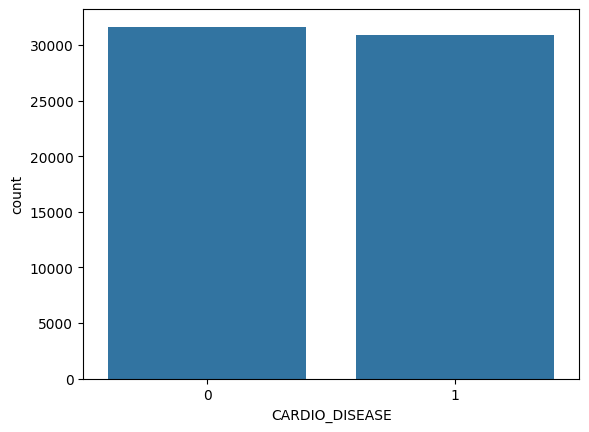

In [14]:
sns.countplot(x='CARDIO_DISEASE', data=df_cleaned)
plt.show()

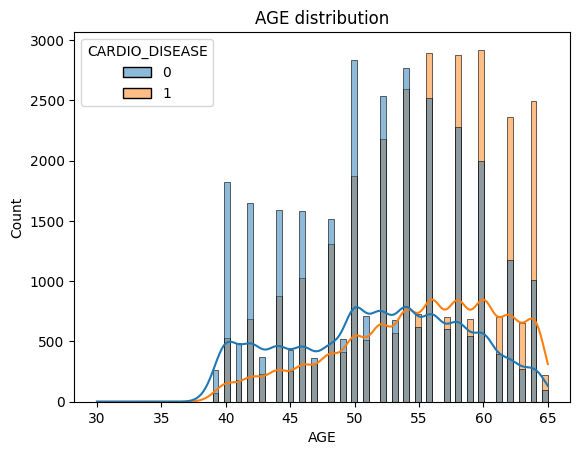

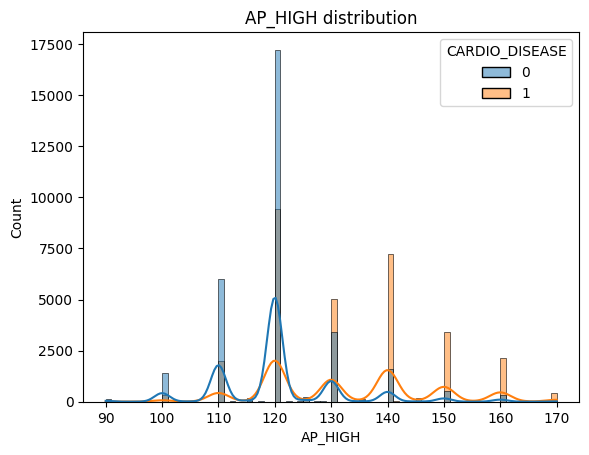

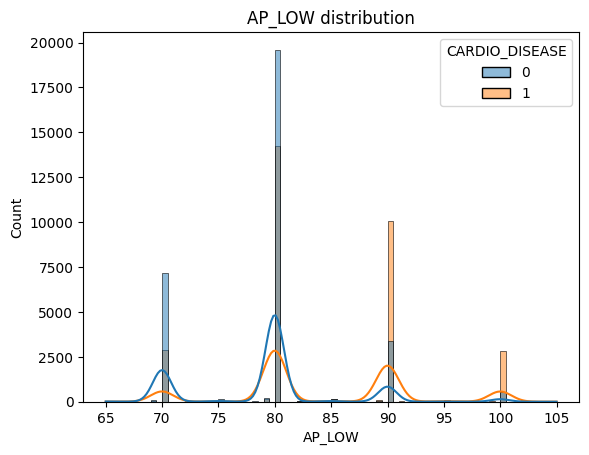

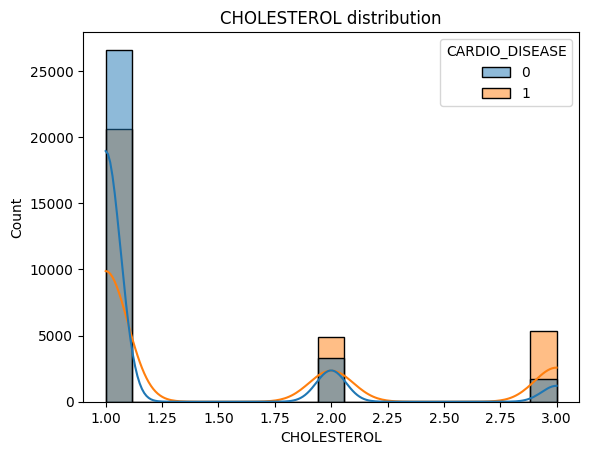

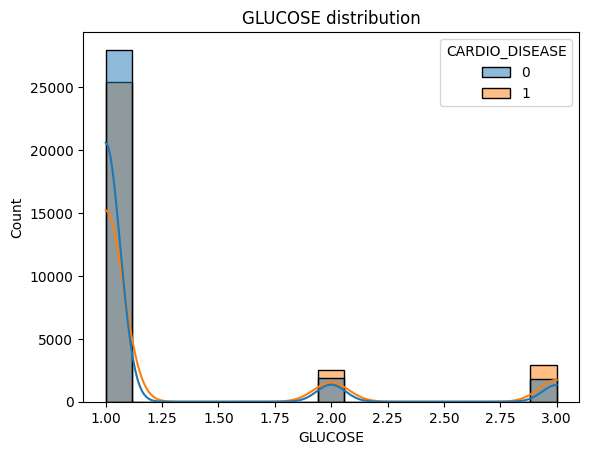

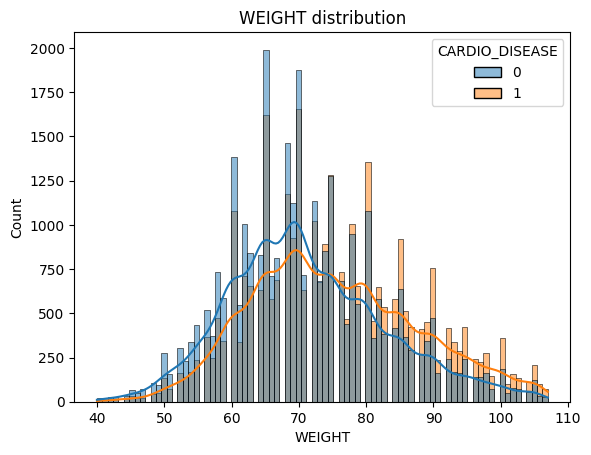

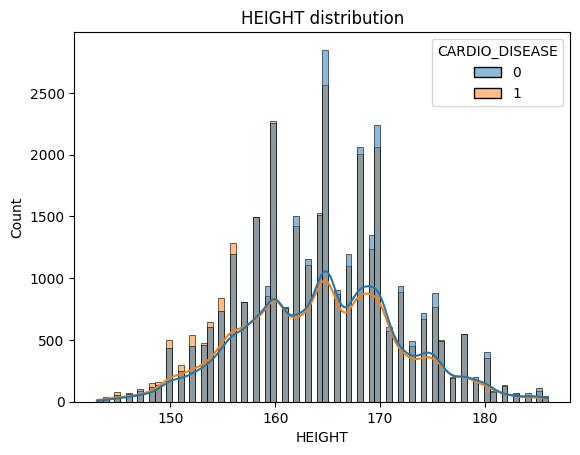

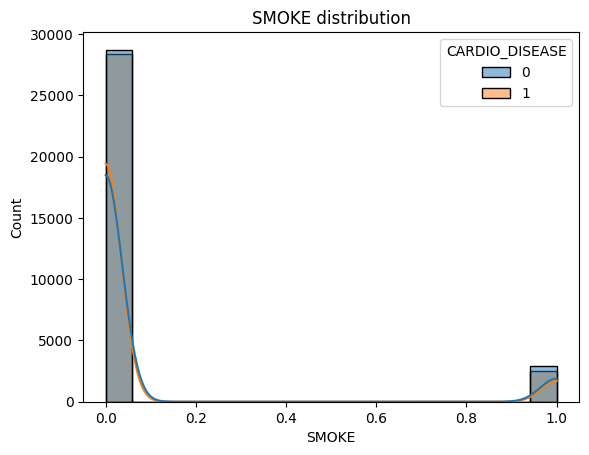

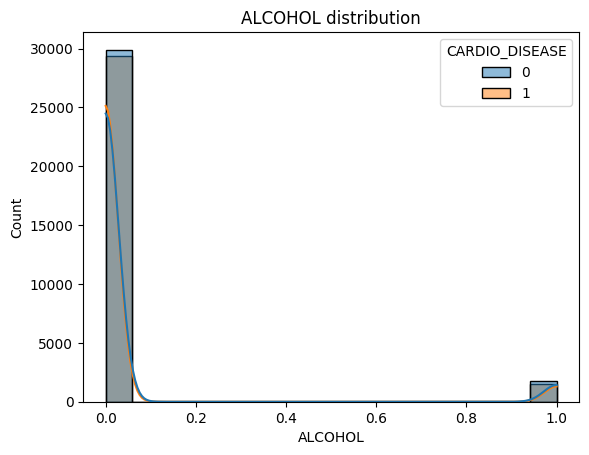

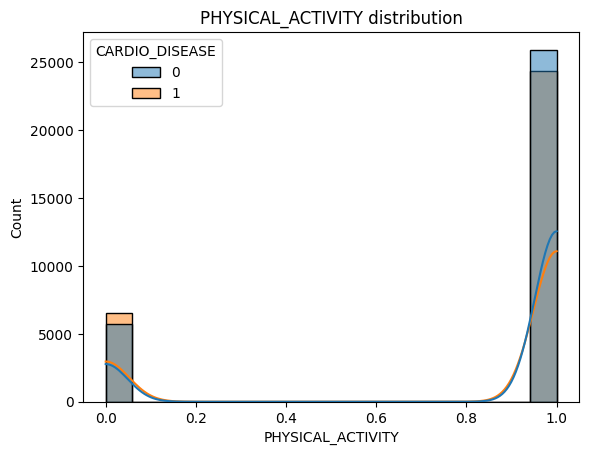

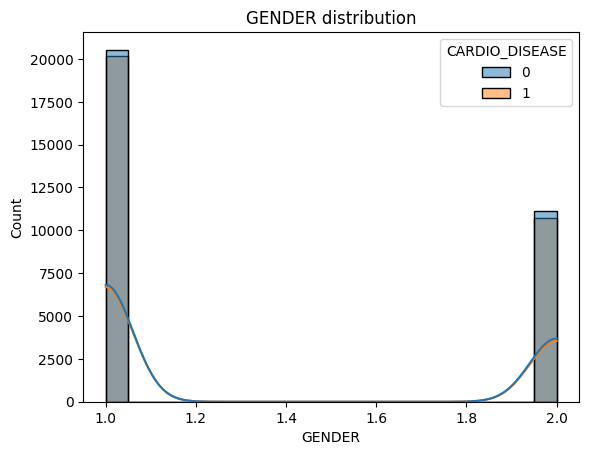

In [15]:
features = ['AGE', 'AP_HIGH', 'AP_LOW', 'CHOLESTEROL', 'GLUCOSE', 'WEIGHT', 'HEIGHT','SMOKE', 'ALCOHOL', 'PHYSICAL_ACTIVITY', 'GENDER']

for col in features:
    plt.figure()
    sns.histplot(data=df_cleaned, x=col, hue='CARDIO_DISEASE', kde=True)
    plt.title(f"{col} distribution")
    plt.show()

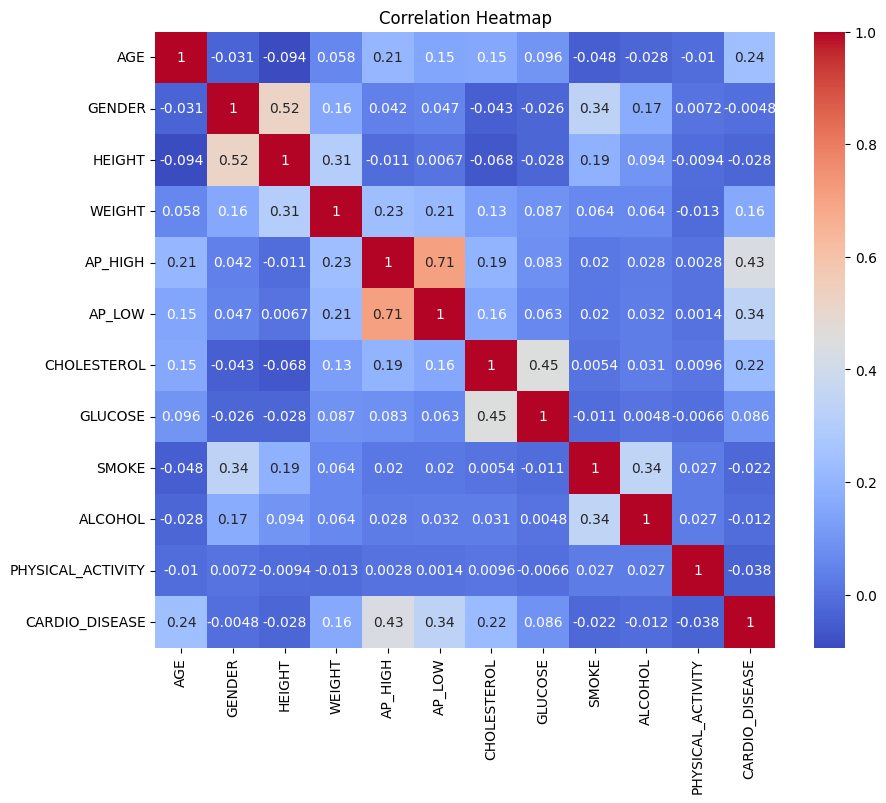

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering ##

In [17]:
df_cleaned['BMI'] = df_cleaned['WEIGHT'] / ((df_cleaned['HEIGHT'] / 100) ** 2)
df_cleaned[['BMI', 'CARDIO_DISEASE']].corr()

,BMI,CARDIO_DISEASE
BMI,1.000000,0.178902
CARDIO_DISEASE,0.178902,1.000000


In [18]:
df_cleaned['PULSE_PRESSURE'] = df_cleaned['AP_HIGH'] - df_cleaned['AP_LOW']
df_cleaned[['PULSE_PRESSURE', 'CARDIO_DISEASE']].corr()

,PULSE_PRESSURE,CARDIO_DISEASE
PULSE_PRESSURE,1.000000,0.345563
CARDIO_DISEASE,0.345563,1.000000


In [19]:
df_cleaned['MAP'] = (df_cleaned['AP_HIGH'] + 2 * df_cleaned['AP_LOW']) / 3
df_cleaned[['MAP', 'CARDIO_DISEASE']].corr()

,MAP,CARDIO_DISEASE
MAP,1.000000,0.414247
CARDIO_DISEASE,0.414247,1.000000


In [20]:
df_cleaned['RISK_SCORE'] = df_cleaned['AGE'] * df_cleaned['CHOLESTEROL']
df_cleaned[['RISK_SCORE', 'CARDIO_DISEASE']].corr()

,RISK_SCORE,CARDIO_DISEASE
RISK_SCORE,1.000000,0.251543
CARDIO_DISEASE,0.251543,1.000000


In [21]:
df_cleaned['METABOLIC_RISK'] = df_cleaned['CHOLESTEROL'] + df_cleaned['GLUCOSE']
df_cleaned[['METABOLIC_RISK', 'CARDIO_DISEASE']].corr()

,METABOLIC_RISK,CARDIO_DISEASE
METABOLIC_RISK,1.000000,0.184961
CARDIO_DISEASE,0.184961,1.000000


In [22]:
df_cleaned['AGE_BP_RISK'] = df_cleaned['AGE'] * df_cleaned['AP_HIGH']
df_cleaned[['AGE_BP_RISK', 'CARDIO_DISEASE']].corr()

,AGE_BP_RISK,CARDIO_DISEASE
AGE_BP_RISK,1.000000,0.417534
CARDIO_DISEASE,0.417534,1.000000


In [23]:
df_cleaned.head()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,BMI,PULSE_PRESSURE,MAP,RISK_SCORE,METABOLIC_RISK,AGE_BP_RISK
0,50,2,168,62,110,80,1,1,0,0,1,0,21.967120,30,90.000000,50,2,5500
1,55,1,156,85,140,90,3,1,0,0,1,1,34.927679,50,106.666667,165,4,7700
2,52,1,165,64,130,70,3,1,0,0,0,1,23.507805,60,90.000000,156,4,6760
3,48,2,169,82,150,100,1,1,0,0,1,1,28.710479,50,116.666667,48,2,7200
5,60,1,151,67,120,80,2,2,0,0,0,0,29.384676,40,93.333333,120,4,7200


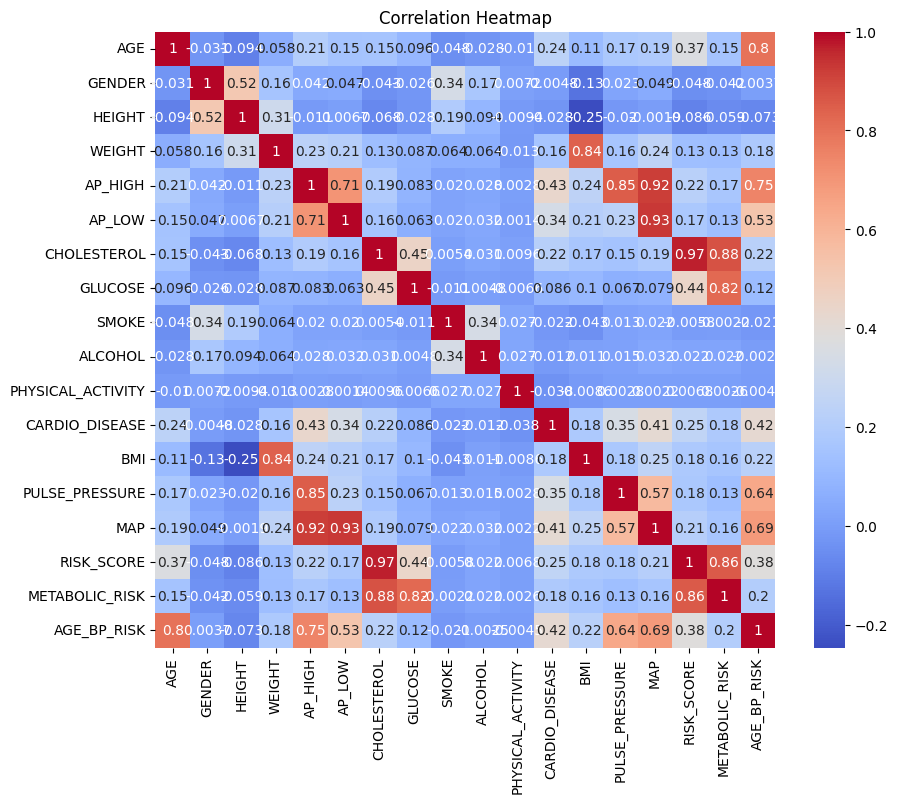

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

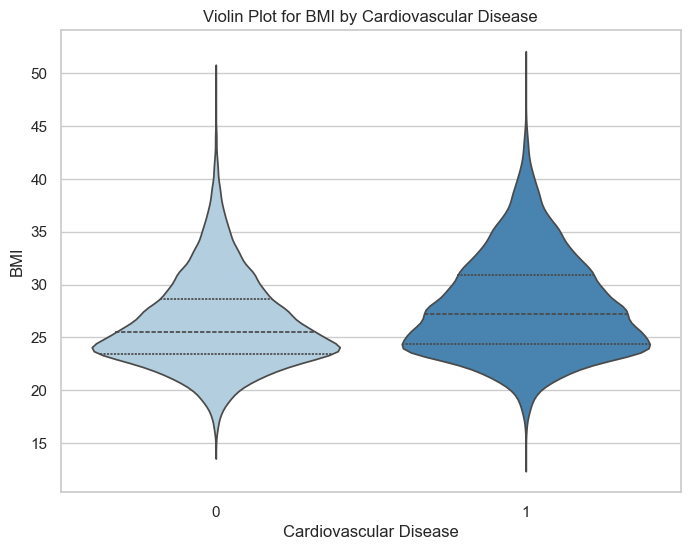

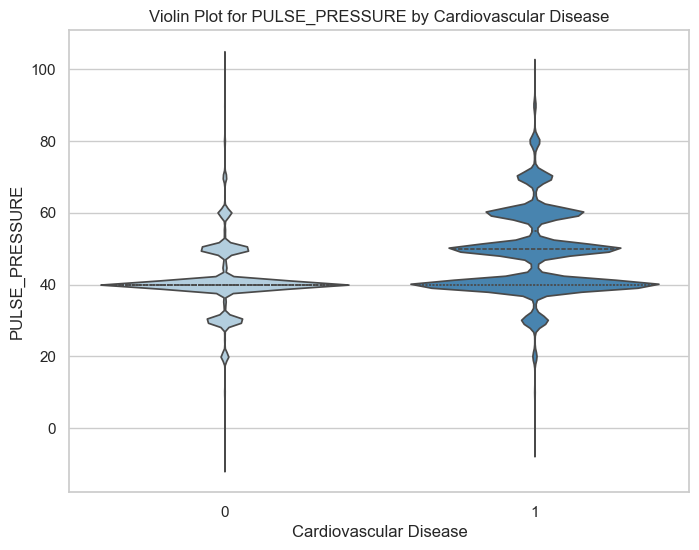

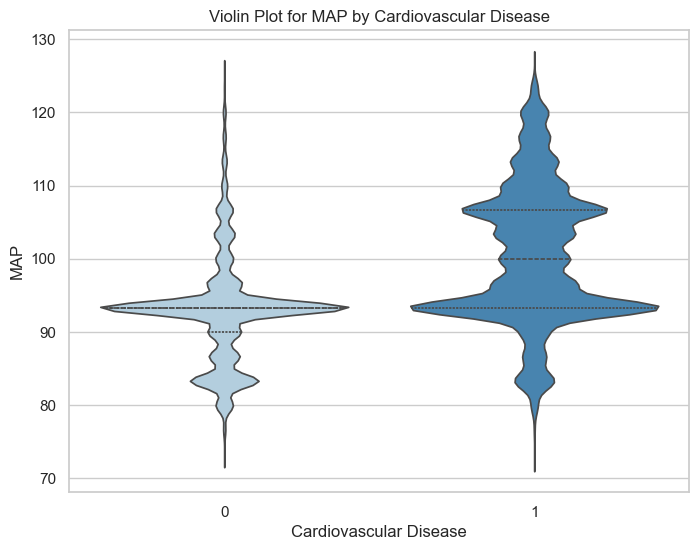

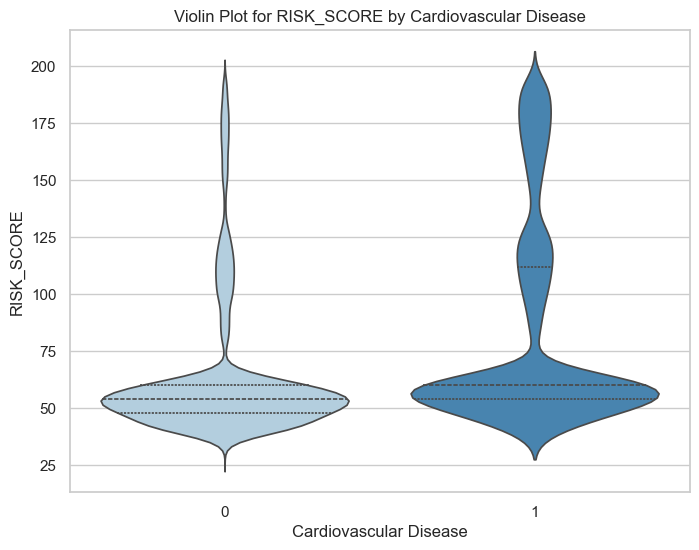

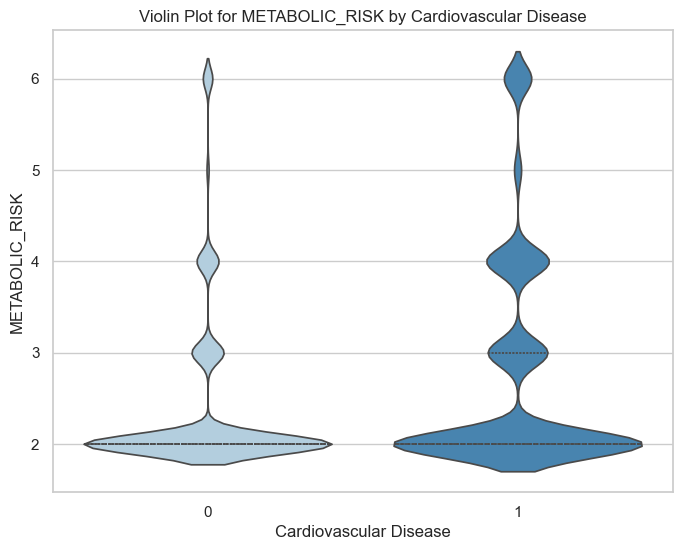

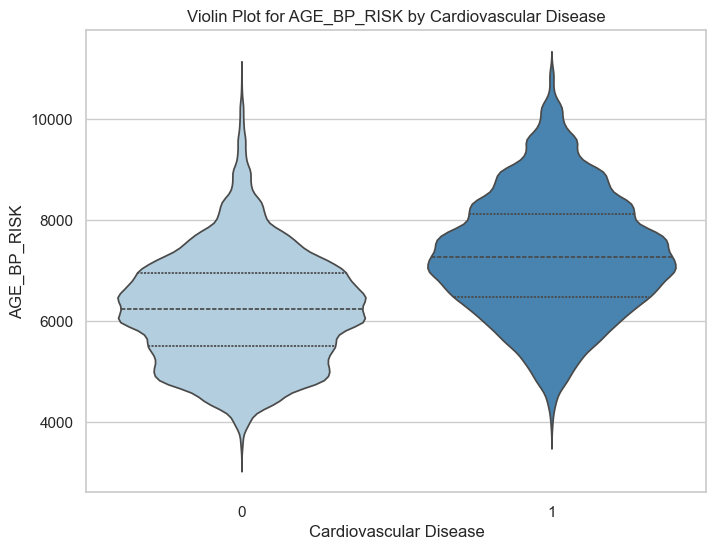

In [25]:
sns.set(style="whitegrid")


features = ['BMI', 'PULSE_PRESSURE', 'MAP', 'RISK_SCORE', 'METABOLIC_RISK', 'AGE_BP_RISK']

for feature in features:
    plt.figure(figsize=(8, 6))
    sns.violinplot(x='CARDIO_DISEASE', y=feature, data=df_cleaned, hue='CARDIO_DISEASE', palette='Blues', inner='quartile', legend=False)
    plt.title(f'Violin Plot for {feature} by Cardiovascular Disease')
    plt.xlabel('Cardiovascular Disease')
    plt.ylabel(feature)
    plt.show()

In [26]:
df_cleaned.to_csv('../cardiovascular_fe.csv', index=False)
print(f"Saved feature-engineered dataset: {df_cleaned.shape}")
print(f"Columns: {list(df_cleaned.columns)}")

Saved feature-engineered dataset: (62513, 18)
Columns: ['AGE', 'GENDER', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW', 'CHOLESTEROL', 'GLUCOSE', 'SMOKE', 'ALCOHOL', 'PHYSICAL_ACTIVITY', 'CARDIO_DISEASE', 'BMI', 'PULSE_PRESSURE', 'MAP', 'RISK_SCORE', 'METABOLIC_RISK', 'AGE_BP_RISK']
